# Trabalho PLN

Para a seguinte base de dados https://www.kaggle.com/brosen255/goodreads-books

Respondam algumas perguntas a partir de experimentos e análise dos dados:

1) Será que apenas pelo título do livro, conseguimos inferir o gênero do autor ? (Fazer um experimento de classificação de texto e utilizar as métricas de classificação)
2) Quem escreve mais páginas, homens ou mulheres ou não há diferença? (Fazer um gráfico)
3) Como é a distribuição de gênero de livro para homens e mulheres? (Fazer um gráfico)
4) Com todos os atributos, fazer um experimento para identificar gênero do autor. Não utilize a coluna gênero do autor nem nome do autor nem id do autor como atributo.

5) Fazer alguma visualização com wordcloud (o material que está no módulo tem o código)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brosen255/goodreads-books")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'goodreads-books' dataset.
Path to dataset files: /kaggle/input/goodreads-books


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

In [ ]:
dataset = pd.read_csv("/root/.cache/kagglehub/datasets/brosen255/goodreads-books/versions/1/good_reads_final.csv")
dataset.head()

,author_average_rating,author_gender,author_genres,author_id,author_name,author_page_url,author_rating_count,author_review_count,birthplace,book_average_rating,book_fullurl,book_id,book_title,genre_1,genre_2,num_ratings,num_reviews,pages,publish_date,score
0,4.01,female,"historical-fiction,",74489,Victoria Thompson\n,/author/show/74489.Victoria_Thompson,74399,6268,United States\n,4.02,https://www.goodreads.com/book/show/686717.Mur...,686717,\n Murder on St. Mark's Place\n,Mystery,Historical,5260,375,277,2000,3230
1,4.15,male,"literature-fiction,mystery-thrillers,",706255,Stieg Larsson\n,/author/show/706255.Stieg_Larsson,3726435,142704,Sweden\n,4.13,https://www.goodreads.com/book/show/2429135.Th...,2429135,\n The Girl with the Dragon Tattoo\n,Fiction,Mystery,2229163,65227,465,August 2005,3062
2,4.00,female,"romance,",5618190,Mimi Jean Pamfiloff\n,/author/show/5618190.Mimi_Jean_Pamfiloff,76496,7975,United States\n,3.99,https://www.goodreads.com/book/show/27833684-t...,27833684,\n Tailored for Trouble\n,Romance,Contemporary,2151,391,354,2016,4585
3,3.88,male,"fiction,memoir,",37871,José Donoso\n,/author/show/37871.Jos_Donoso,5522,489,Chile\n,4.14,https://www.goodreads.com/book/show/382975.The...,382975,\n The Obscene Bird of Night\n,Fiction,Magical Realism,1844,173,438,1970,1533
4,4.10,female,"young-adult,fantasy,",36122,Patricia C. Wrede\n,/author/show/36122.Patricia_C_Wrede,291013,13453,United States\n,4.01,https://www.goodreads.com/book/show/64207.Sorc...,64207,\n Sorcery & Cecelia: or The Enchanted Ch...,Fantasy,Young Adult,17051,1890,326,April 15th 1988,2105


# Questão 01
Será que apenas pelo título do livro, conseguimos inferir o gênero do autor ? (Fazer um experimento de classificação de texto e utilizar as métricas de classificação)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Limpeza de dados

df_q1 = dataset[['book_title', 'author_gender', 'author_id']].copy()

df_q1 = df_q1.dropna(subset=['book_title', 'author_gender'])

# Apenas "male" e "female"

df_q1 = df_q1[
    df_q1['author_gender'].isin(['male', 'female'])
]

print("Quantidade de registros:", len(df_q1))
print("\nDistribuição das classes:")
print(df_q1['author_gender'].value_counts())

# Variáveis

X = df_q1['book_title']
y = df_q1['author_gender']
grupos = df_q1['author_id']

# Divisão de treino e teste

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=grupos)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTreino:", len(X_train))
print("Teste :", len(X_test))

# TF-IDF

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nDimensão da matriz TF-IDF:")
print(X_train_tfidf.shape)

# Treino

modelo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train_tfidf, y_train)
y_pred = modelo.predict(X_test_tfidf)

Quantidade de registros: 22891

Distribuição das classes:
author_gender
male      12201
female    10690
Name: count, dtype: int64

Treino: 18329
Teste : 4562

Dimensão da matriz TF-IDF:
(18329, 5191)


In [ ]:
# Avaliação de métricas

acuracia = accuracy_score(y_test, y_pred)

print("RESULTADOS")

print(f"\nAcurácia: {acuracia:.4f}")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

RESULTADOS

Acurácia: 0.5633

Relatório de Classificação:
              precision    recall  f1-score   support

      female       0.54      0.40      0.46      2116
        male       0.58      0.70      0.63      2446

    accuracy                           0.56      4562
   macro avg       0.56      0.55      0.55      4562
weighted avg       0.56      0.56      0.55      4562



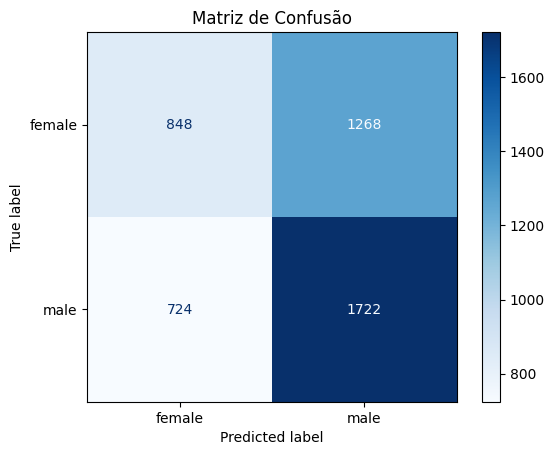

In [ ]:
# Matriz de confusão

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo.classes_
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.show()

In [ ]:
# Análise de palavras mais associadas aos autores

feature_names = np.array(vectorizer.get_feature_names_out())

coeficientes = modelo.coef_[0]

top_male = np.argsort(coeficientes)[-20:]
top_female = np.argsort(coeficientes)[:20]

print("PALAVRAS MAIS ASSOCIADAS A AUTORES HOMENS")

for indice in reversed(top_male):
    print(feature_names[indice])

print("PALAVRAS MAIS ASSOCIADAS A AUTORAS")

for indice in top_female:
    print(feature_names[indice])

PALAVRAS MAIS ASSOCIADAS A AUTORES HOMENS
batman
war
في
owl
wars
sleep
times
saga
world
edition
crucible
lincoln
long
battle
hollow
land
words
jungle
money
dry
PALAVRAS MAIS ASSOCIADAS A AUTORAS
daughter
honor
daddy
unseen
perfect
roses
goddess
ember
chocolate
siren
comfort
branded
girls
obsession
news
forbidden
bride
seduction
bet
rebecca


# Questão 02
Quem escreve mais páginas, homens ou mulheres ou não há diferença? (Fazer um gráfico)

Média de páginas por gênero:


,author_gender,pages
0,female,323.418896
1,male,341.389162


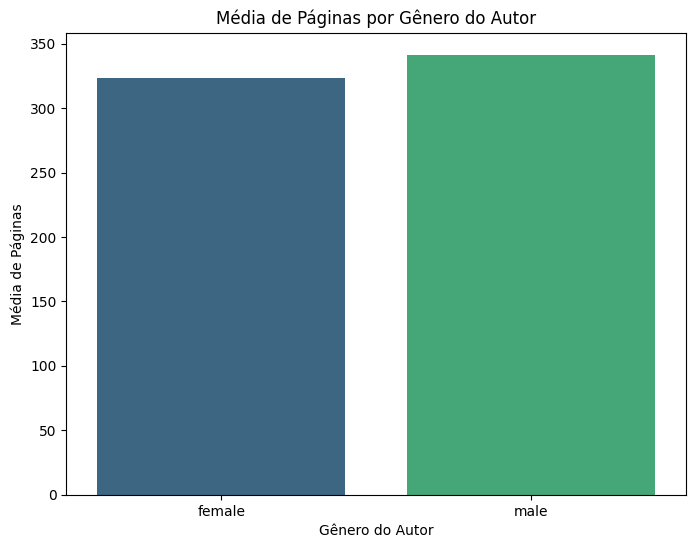

In [ ]:
dataset['pages'] = pd.to_numeric(dataset['pages'], errors='coerce')

paginas_por_genero = dataset.groupby('author_gender')['pages'].mean().reset_index()

print("Média de páginas por gênero:")
display(paginas_por_genero)

plt.figure(figsize=(8, 6))
sns.barplot(data=paginas_por_genero, x='author_gender', y='pages', hue='author_gender', palette='viridis')
plt.title('Média de Páginas por Gênero do Autor')
plt.xlabel('Gênero do Autor')
plt.ylabel('Média de Páginas')
plt.show()

# Questão 03

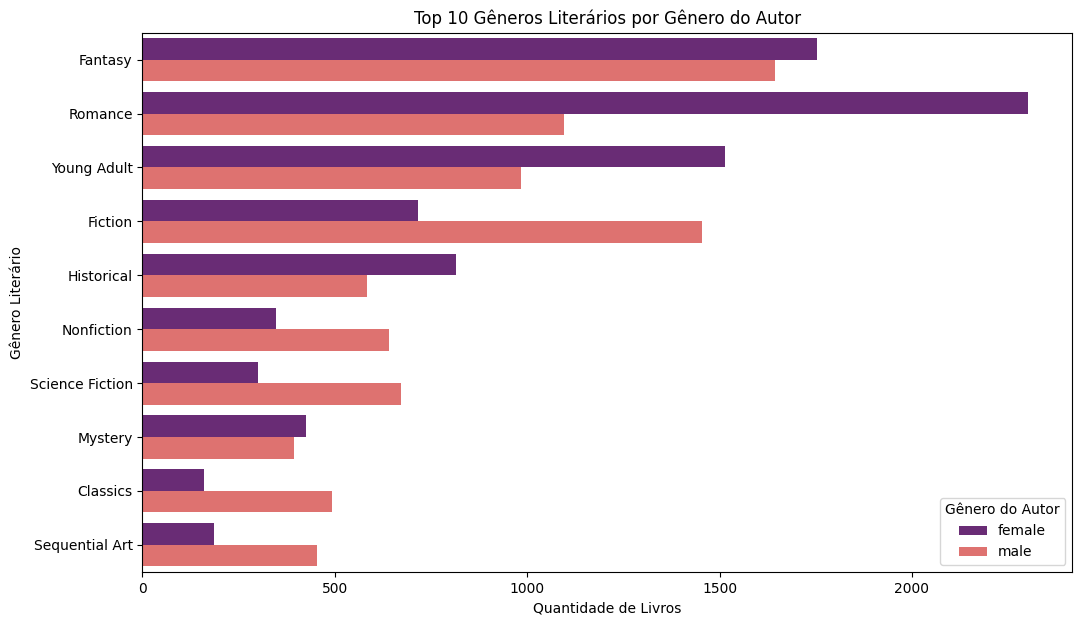

In [ ]:
top_genres = dataset['genre_1'].value_counts().nlargest(10).index
df_top_genres = dataset[dataset['genre_1'].isin(top_genres)]

plt.figure(figsize=(12, 7))
sns.countplot(data=df_top_genres, y='genre_1', hue='author_gender', palette='magma', order=top_genres)

plt.title('Top 10 Gêneros Literários por Gênero do Autor')
plt.xlabel('Quantidade de Livros')
plt.ylabel('Gênero Literário')
plt.legend(title='Gênero do Autor')
plt.show()

# Questão 04
Com todos os atributos, fazer um experimento para identificar gênero do autor. Não utilize a coluna gênero do autor nem nome do autor nem id do autor como atributo.

In [ ]:
df_q4 = dataset.dropna(subset=['author_gender']).copy()

#Features
target = 'author_gender'
numeric_features = ['author_average_rating', 'author_rating_count', 'author_review_count', 'book_average_rating', 'num_ratings', 'num_reviews', 'pages', 'score']
categorical_features = ['genre_1', 'genre_2']

df_q4['pages'] = pd.to_numeric(df_q4['pages'], errors='coerce')

#Pipeline de Pré-processamento
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)])

#Modelo Final
clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])

#Treino e Teste
X_q4 = df_q4[numeric_features + categorical_features]
y_q4 = df_q4[target]

X_train_q4, X_test_q4, y_train_q4, y_test_q4 = train_test_split(X_q4, y_q4, test_size=0.2, random_state=42)

#Treinamento
clf.fit(X_train_q4, y_train_q4)

#Predição e Resultados
y_pred_q4 = clf.predict(X_test_q4)

print("--- Experimento com todos os atributos (exceto nomes/ids) ---")
print(f"Acurácia: {accuracy_score(y_test_q4, y_pred_q4):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test_q4, y_pred_q4))

--- Experimento com todos os atributos (exceto nomes/ids) ---
Acurácia: 0.8002

Relatório de Classificação:
              precision    recall  f1-score   support

      female       0.79      0.79      0.79      2151
        male       0.81      0.81      0.81      2428

    accuracy                           0.80      4579
   macro avg       0.80      0.80      0.80      4579
weighted avg       0.80      0.80      0.80      4579



# Questão 05
Fazer alguma visualização com wordcloud (o material que está no módulo tem o código)

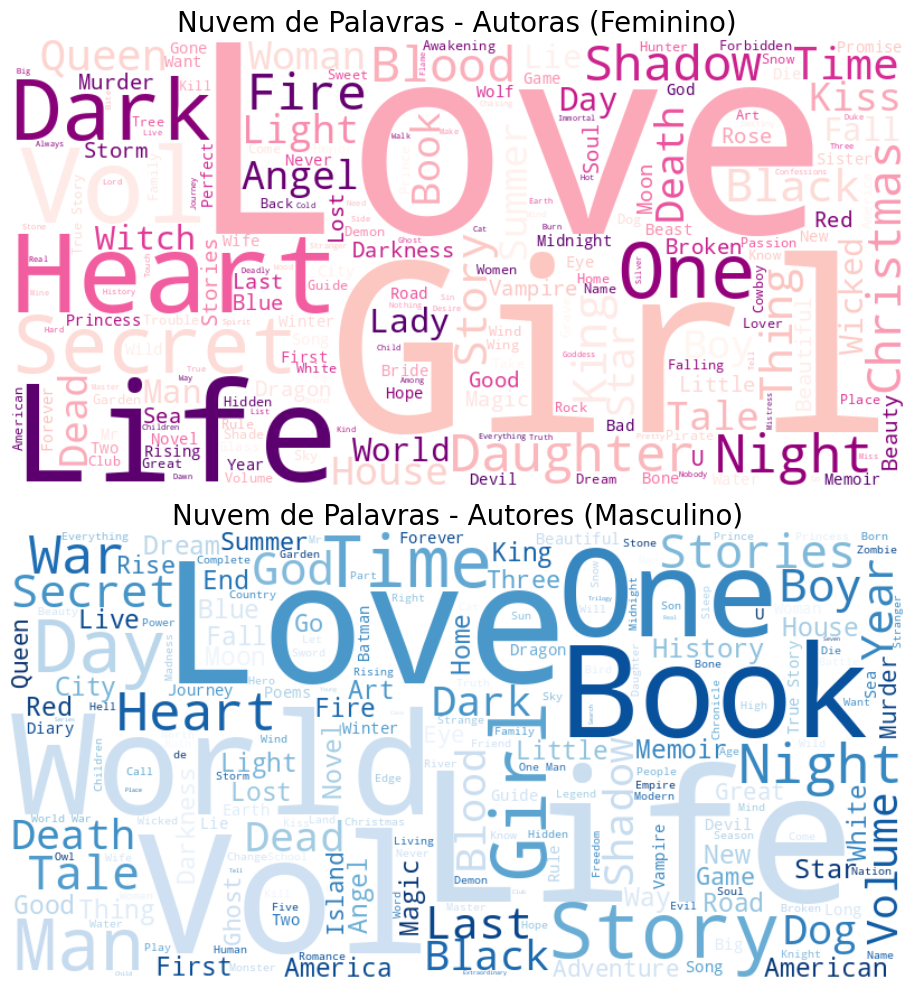

In [ ]:
titles_female = dataset[dataset['author_gender'] == 'female']['book_title'].dropna().astype(str)
titles_male = dataset[dataset['author_gender'] == 'male']['book_title'].dropna().astype(str)

text_female = " ".join(titles_female)
text_male = " ".join(titles_male)

wc_female = WordCloud(width=800, height=400, background_color='white', colormap='RdPu').generate(text_female)
wc_male = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(text_male)

plt.figure(figsize=(16, 10))

plt.subplot(2, 1, 1)
plt.imshow(wc_female, interpolation='bilinear')
plt.title('Nuvem de Palavras - Autoras (Feminino)', fontsize=20)
plt.axis('off')
plt.subplot(2, 1, 2)
plt.imshow(wc_male, interpolation='bilinear')
plt.title('Nuvem de Palavras - Autores (Masculino)', fontsize=20)
plt.axis('off')
plt.tight_layout()

plt.show()